In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import talib
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import yfinance as yf
import os
import random

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.preprocessing import MinMaxScaler, StandardScaler

from IPython.display import clear_output

%matplotlib inline

pd.set_option('display.max_columns', None)

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
def seed_everything_pt(seed: int = 42) -> None:
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Using {seed} seed")
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

In [4]:
seed_everything_pt()

Using 42 seed


In [5]:
# Загрузим из файла
eth_df = pd.read_csv('../data/eth_df_features.csv').set_index('Datetime')
eth_df.index = pd.to_datetime(eth_df.index)
eth_df 

,Open,High,Low,Close,Volume,Open_lag_3,High_lag_3,Low_lag_3,Close_lag_3,Volume_lag_3,Open_lag_9,High_lag_9,Low_lag_9,Close_lag_9,Volume_lag_9,Open_lag_15,High_lag_15,Low_lag_15,Close_lag_15,Volume_lag_15,Open_lag_30,High_lag_30,Low_lag_30,Close_lag_30,Volume_lag_30,Close_SMA_6,Close_SMA_9,Close_SMA_30,Close_SMA_50,Close_RSI_4,Close_RSI_9,Close_RSI_20,Close_mean_3,Close_median_3,Close_min_3,Close_max_3,Close_std_3,Close_range_3,Close_mean_10,Close_median_10,Close_min_10,Close_max_10,Close_std_10,Close_range_10,Close_mean_30,Close_median_30,Close_min_30,Close_max_30,Close_std_30,Close_range_30,Close_mean_50,Close_median_50,Close_min_50,Close_max_50,Close_std_50,Close_range_50,High-Low,Close_ratio_1,Close_log_diff_1,Close_momentum_3,Close_roc_3,Close_momentum_10,Close_roc_10,Close_momentum_30,Close_roc_30,Close_momentum_50,Close_roc_50,Month,Weekday,Hour
Datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-01-01 12:45:00,2306.29,2306.27,2299.20,2299.49,493,2304.50,2306.54,2300.81,2300.90,259.0,2299.20,2300.98,2299.20,2300.90,359.0,2287.07,2291.40,2287.00,2289.89,896.0,2283.00,2283.22,2277.11,2278.59,433.0,2302.315000,2302.423333,2291.412667,2289.9810,39.303868,52.062178,55.042475,2302.960000,2303.10,2299.49,2306.29,3.402161,6.80,2302.271,2302.260,2299.49,2306.29,2.151457,6.80,2291.412667,2289.845,2274.80,2306.29,10.151109,31.49,2289.9810,2289.845,2271.77,2306.29,10.456837,34.52,7.07,0.997052,-0.002953,-1.41,-0.061280,0.29,0.012613,20.90,0.917234,8.59,0.374962,1,0,12
2024-01-01 13:00:00,2299.49,2303.59,2298.18,2303.30,355,2300.90,2303.20,2300.01,2303.10,197.0,2300.90,2303.30,2300.70,2302.29,301.0,2289.89,2292.08,2288.00,2289.80,450.0,2278.59,2280.19,2276.29,2279.10,293.0,2302.930000,2302.535556,2292.219333,2290.1832,54.480373,58.599008,58.119619,2303.026667,2303.30,2299.49,2306.29,3.408230,6.80,2302.511,2302.695,2299.49,2306.29,2.115081,6.80,2292.219333,2293.395,2274.80,2306.29,10.100343,31.49,2290.1832,2289.845,2271.77,2306.29,10.616679,34.52,5.41,1.001657,0.001656,0.20,0.008684,2.40,0.104307,24.20,1.061823,10.11,0.440871,1,0,13
2024-01-01 13:15:00,2303.30,2306.79,2303.30,2306.49,238,2303.10,2307.20,2302.27,2306.29,536.0,2302.29,2305.24,2301.81,2303.40,534.0,2289.80,2298.06,2289.80,2296.90,861.0,2279.10,2279.20,2272.60,2275.80,323.0,2303.261667,2302.878889,2293.242333,2290.4008,64.413759,63.311370,60.502265,2303.093333,2303.30,2299.49,2306.49,3.504573,7.00,2302.931,2303.200,2299.49,2306.49,2.455870,7.00,2293.242333,2298.050,2274.80,2306.49,9.932795,31.69,2290.4008,2289.845,2271.77,2306.49,10.839341,34.72,3.49,1.001385,0.001384,0.20,0.008672,4.20,0.182427,30.69,1.348537,10.88,0.473948,1,0,13
2024-01-01 13:30:00,2306.49,2307.48,2303.80,2307.48,258,2306.29,2306.27,2299.20,2299.49,493.0,2303.40,2304.20,2300.41,2302.23,272.0,2296.90,2299.81,2296.81,2299.79,386.0,2275.80,2278.30,2274.20,2274.80,573.0,2304.358333,2303.462222,2294.331667,2290.6224,67.361019,64.713641,61.222949,2305.756667,2306.49,2303.30,2307.48,2.184361,4.18,2303.339,2303.200,2299.49,2307.48,2.849766,7.99,2294.331667,2299.345,2276.09,2307.48,9.627805,31.39,2290.6224,2289.845,2271.77,2307.48,11.075186,35.71,3.68,1.000429,0.000429,7.99,0.347468,4.08,0.177129,32.68,1.436610,11.08,0.482494,1,0,13
2024-01-01 13:45:00,2307.48,2308.17,2304.20,2304.20,914,2299.49,2303.59,2298.18,2303.30,355.0,2302.23,2303.10,2299.14,2299.61,228.0,2299.79,2302.39,2299.70,2300.40,430.0,2274.80,2280.32,2274.21,2276.09,742.0,2304.541667,2303.972222,2295.268667,2290.7274,49.317696,56.644143,57.560179,2306.056667,2306.49,2304.20,2307.48,1.682389,3.28,2303.536,2303.750,2299.49,2307.48,2.832624,7.99,2295.268667,2299.550,2281.01,2307.48,9.147132,26.47,2290.7274,2289.845,2271.77,2307.48,11.180138,35.71,3.97,0.998579,-0.001422,0.90,0.039074,1.97,0.085569,28.11,1.235013,5.25,0.228365,1,0,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,

# Попробуем предсказывать тренд через час. 

In [6]:
def add_target_column(data, close_col='Close', threshold=1, periods=4):
    """
    Добавляет колонку target в датафрейм на основе процентного изменения цены через час.

    - df: Исходный датафрейм.
    - close_col: Название колонки с ценами закрытия.
    - threshold: Пороговое значение процента для классификации.
    - periods: Количество периодов вперед для расчета процентного изменения цены.
    """
    df = data.copy()
    # Рассчитываем процентное изменение цены через час
    df['price_change_pct'] = df[close_col].pct_change(periods=periods).shift(-periods) * 100

    # Создаем колонку target на основе условий
    df['target'] = np.select(
        [
            df['price_change_pct'] < -threshold,  # Цена упала на threshold и больше
            (df['price_change_pct'] >= -threshold) & (df['price_change_pct'] <= threshold),  # Цена в пределах threshold
            df['price_change_pct'] > threshold  # Цена выросла на threshold и больше
        ],
        [0, 1, 2],  # Соответствующие классы (0: упала, 1: в пределах, 2: выросла)
        default=np.nan  # Если значение NaN (последние 4 строки)
    )

    # Удаляем временную колонку price_change_pct
    df.drop(columns=['price_change_pct'], inplace=True)

    # Удаляем строки с NaN в target
    df.dropna(subset=['target'], inplace=True)

    # Преобразуем target в целые числа
    df['target'] = df['target'].astype(int)

    return df

In [7]:
eth_df_target = add_target_column(eth_df, threshold=0.15)
eth_df_target

,Open,High,Low,Close,Volume,Open_lag_3,High_lag_3,Low_lag_3,Close_lag_3,Volume_lag_3,Open_lag_9,High_lag_9,Low_lag_9,Close_lag_9,Volume_lag_9,Open_lag_15,High_lag_15,Low_lag_15,Close_lag_15,Volume_lag_15,Open_lag_30,High_lag_30,Low_lag_30,Close_lag_30,Volume_lag_30,Close_SMA_6,Close_SMA_9,Close_SMA_30,Close_SMA_50,Close_RSI_4,Close_RSI_9,Close_RSI_20,Close_mean_3,Close_median_3,Close_min_3,Close_max_3,Close_std_3,Close_range_3,Close_mean_10,Close_median_10,Close_min_10,Close_max_10,Close_std_10,Close_range_10,Close_mean_30,Close_median_30,Close_min_30,Close_max_30,Close_std_30,Close_range_30,Close_mean_50,Close_median_50,Close_min_50,Close_max_50,Close_std_50,Close_range_50,High-Low,Close_ratio_1,Close_log_diff_1,Close_momentum_3,Close_roc_3,Close_momentum_10,Close_roc_10,Close_momentum_30,Close_roc_30,Close_momentum_50,Close_roc_50,Month,Weekday,Hour,target
Datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-01-01 12:45:00,2306.29,2306.27,2299.20,2299.49,493,2304.50,2306.54,2300.81,2300.90,259.0,2299.20,2300.98,2299.20,2300.90,359.0,2287.07,2291.40,2287.00,2289.89,896.0,2283.00,2283.22,2277.11,2278.59,433.0,2302.315000,2302.423333,2291.412667,2289.9810,39.303868,52.062178,55.042475,2302.960000,2303.10,2299.49,2306.29,3.402161,6.80,2302.271,2302.260,2299.49,2306.29,2.151457,6.80,2291.412667,2289.845,2274.80,2306.29,10.151109,31.49,2289.9810,2289.845,2271.77,2306.29,10.456837,34.52,7.07,0.997052,-0.002953,-1.41,-0.061280,0.29,0.012613,20.90,0.917234,8.59,0.374962,1,0,12,2
2024-01-01 13:00:00,2299.49,2303.59,2298.18,2303.30,355,2300.90,2303.20,2300.01,2303.10,197.0,2300.90,2303.30,2300.70,2302.29,301.0,2289.89,2292.08,2288.00,2289.80,450.0,2278.59,2280.19,2276.29,2279.10,293.0,2302.930000,2302.535556,2292.219333,2290.1832,54.480373,58.599008,58.119619,2303.026667,2303.30,2299.49,2306.29,3.408230,6.80,2302.511,2302.695,2299.49,2306.29,2.115081,6.80,2292.219333,2293.395,2274.80,2306.29,10.100343,31.49,2290.1832,2289.845,2271.77,2306.29,10.616679,34.52,5.41,1.001657,0.001656,0.20,0.008684,2.40,0.104307,24.20,1.061823,10.11,0.440871,1,0,13,0
2024-01-01 13:15:00,2303.30,2306.79,2303.30,2306.49,238,2303.10,2307.20,2302.27,2306.29,536.0,2302.29,2305.24,2301.81,2303.40,534.0,2289.80,2298.06,2289.80,2296.90,861.0,2279.10,2279.20,2272.60,2275.80,323.0,2303.261667,2302.878889,2293.242333,2290.4008,64.413759,63.311370,60.502265,2303.093333,2303.30,2299.49,2306.49,3.504573,7.00,2302.931,2303.200,2299.49,2306.49,2.455870,7.00,2293.242333,2298.050,2274.80,2306.49,9.932795,31.69,2290.4008,2289.845,2271.77,2306.49,10.839341,34.72,3.49,1.001385,0.001384,0.20,0.008672,4.20,0.182427,30.69,1.348537,10.88,0.473948,1,0,13,0
2024-01-01 13:30:00,2306.49,2307.48,2303.80,2307.48,258,2306.29,2306.27,2299.20,2299.49,493.0,2303.40,2304.20,2300.41,2302.23,272.0,2296.90,2299.81,2296.81,2299.79,386.0,2275.80,2278.30,2274.20,2274.80,573.0,2304.358333,2303.462222,2294.331667,2290.6224,67.361019,64.713641,61.222949,2305.756667,2306.49,2303.30,2307.48,2.184361,4.18,2303.339,2303.200,2299.49,2307.48,2.849766,7.99,2294.331667,2299.345,2276.09,2307.48,9.627805,31.39,2290.6224,2289.845,2271.77,2307.48,11.075186,35.71,3.68,1.000429,0.000429,7.99,0.347468,4.08,0.177129,32.68,1.436610,11.08,0.482494,1,0,13,0
2024-01-01 13:45:00,2307.48,2308.17,2304.20,2304.20,914,2299.49,2303.59,2298.18,2303.30,355.0,2302.23,2303.10,2299.14,2299.61,228.0,2299.79,2302.39,2299.70,2300.40,430.0,2274.80,2280.32,2274.21,2276.09,742.0,2304.541667,2303.972222,2295.268667,2290.7274,49.317696,56.644143,57.560179,2306.056667,2306.49,2304.20,2307.48,1.682389,3.28,2303.536,2303.750,2299.49,2307.48,2.832624,7.99,2295.268667,2299.550,2281.01,2307.48,9.147132,26.47,2290.7274,2289.845,2271.77,2307.48,11.180138,35.71,3.97,0.998579,-0.001422,0.90,0.039074,1.97,0.085569,28.11,1.235013,5.25,0.228365,1,0,13,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

In [8]:
print("Количество каждого класса:")
print(eth_df_target['target'].value_counts())


Количество каждого класса:
target
2    26865
0    25384
1    20272
Name: count, dtype: int64


При threshold=0.15% классы сбалансированы

In [9]:

val_size = int(0.15 * len(eth_df_target))  # Размер валидационной выборки
test_size = val_size  # Размер тестовой выборки

# Валидационная выборка
val_df = eth_df_target.iloc[-(val_size + test_size):-test_size]

# Тестовая выборка
test_df = eth_df_target.iloc[-test_size:]

# Обучающая выборка (все остальные данные)
train_df = eth_df_target.iloc[:-(val_size + test_size)]

# Проверка размеров выборок
print(f"Размер обучающей выборки (train): {len(train_df)}")
print(f"Размер валидационной выборки (val): {len(val_df)}")
print(f"Размер тестовой выборки (test): {len(test_df)}")

print("Количество каждого класса в обучающей выборке:")
print(train_df['target'].value_counts())

print("Количество каждого класса в валидационной выборке:")
print(val_df['target'].value_counts())

print("Количество каждого класса в тестовой выборке:")
print(test_df['target'].value_counts())

Размер обучающей выборки (train): 50765
Размер валидационной выборки (val): 10878
Размер тестовой выборки (test): 10878
Количество каждого класса в обучающей выборке:
target
2    18956
0    17887
1    13922
Name: count, dtype: int64
Количество каждого класса в валидационной выборке:
target
2    4063
0    3721
1    3094
Name: count, dtype: int64
Количество каждого класса в тестовой выборке:
target
2    3846
0    3776
1    3256
Name: count, dtype: int64


разбиение на train, val, test не сместило баланс классов

In [10]:
# Проверим правильность разбиения по времени
print(train_df['Close'].head(1))
print(train_df['Close'].tail(1))
print()
print(val_df['Close'].head(1))
print(val_df['Close'].tail(1))
print()
print(test_df['Close'].head(1))
print(test_df['Close'].tail(1))


Datetime
2024-01-01 12:45:00    2299.49
Name: Close, dtype: float64
Datetime
2025-06-13 07:45:00    2526.92
Name: Close, dtype: float64

Datetime
2025-06-13 08:00:00    2539.58
Name: Close, dtype: float64
Datetime
2025-10-04 15:15:00    4453.14
Name: Close, dtype: float64

Datetime
2025-10-04 15:30:00    4458.07
Name: Close, dtype: float64
Datetime
2026-01-25 22:45:00    2807.22
Name: Close, dtype: float64


In [11]:
# Разделяем данные на фичи и целевую переменную
features_train = train_df.drop(columns=['target'])
target_train = train_df['target']

features_val = val_df.drop(columns=['target'])
target_val = val_df['target']

features_test = test_df.drop(columns=['target'])
target_test = test_df['target']

In [12]:
import pickle

# Функция для нормализации данных
def normalize_dataframe(data, scaler="StandardScaler", save_scaler=True, scaler_file="scaler.pkl"):
    """Функция нормализует DataFrame с использованием заданного скейлера.

    df (pd.DataFrame): Датафрейм для нормализации.
    scaler (str or sklearn Scaler): Имя скейлера ("StandardScaler", "MinMaxScaler", "RobustScaler") 
                                     или уже обученный объект скейлера.
    save_scaler (bool): сохранять ли scaler в файл (по умолчанию: сохранять)
    scaler_file (str): Имя файла, куда сохраняется обученный скейлер (по умолчанию: "scaler.pkl").

    """
    from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

    df = data.copy()

    if isinstance(scaler, str):
        # Создаем скейлер на основе переданного имени
        if scaler == "StandardScaler":
            scaler = StandardScaler()
        elif scaler == "MinMaxScaler":
            scaler = MinMaxScaler()
        elif scaler == "RobustScaler":
            scaler = RobustScaler()
        else:
            raise ValueError(f"Неизвестный скейлер: {scaler}")

        # Обучаем скейлер на датафрейме
        scaler.fit(df)

        # Сохраняем обученный скейлер в файл
        if save_scaler:
            with open(scaler_file, "wb") as f:
                pickle.dump(scaler, f)
    elif hasattr(scaler, "transform"):
        # Если передан обученный скейлер, просто используем его
        pass
    else:
        raise ValueError("Передан некорректный скейлер. Должна быть строка 'StandardScaler', 'MinMaxScaler', 'RobustScaler' или объект sklearn Scaler.")

    # Применяем скейлер к датафрейму
    normalized_data = scaler.transform(df)

    # Возвращаем нормализованный датафрейм и обученный скейлер
    return pd.DataFrame(normalized_data, columns=df.columns, index=df.index), scaler


# Функция для загрузки скейлера из файла
def load_scaler(scaler_file):
    """Загружает скейлер из указанного файла.

    Args:
    scaler_file (str): Путь к файлу, содержащему сохранённый скейлер.

    Return:
    sklearn Scaler: Загруженный объект скейлера.
    """
    with open(scaler_file, "rb") as f:
        scaler = pickle.load(f)
    return scaler

In [13]:
# Нормализация X
X_train_scaled, scaler = normalize_dataframe(features_train, scaler='StandardScaler', save_scaler=True, scaler_file='../scalers/scaler_train.pcl')

# Применение того же scaler к валидационной и тестовой выборкам
X_val_scaled, _ = normalize_dataframe(features_val, scaler=scaler, save_scaler=False)
X_test_scaled, _ = normalize_dataframe(features_test, scaler=scaler, save_scaler=False)

In [14]:
# Создаем новые датафреймы с нормализованными данными
train_scaled_df = pd.DataFrame(X_train_scaled, columns=features_train.columns, index=features_train.index)
val_scaled_df = pd.DataFrame(X_val_scaled, columns=features_val.columns, index=features_val.index)
test_scaled_df = pd.DataFrame(X_test_scaled, columns=features_test.columns, index=features_test.index)

# Добавляем целевую переменную обратно
train_scaled_df['target'] = target_train
val_scaled_df['target'] = target_val
test_scaled_df['target'] = target_test

In [15]:
train_scaled_df

,Open,High,Low,Close,Volume,Open_lag_3,High_lag_3,Low_lag_3,Close_lag_3,Volume_lag_3,Open_lag_9,High_lag_9,Low_lag_9,Close_lag_9,Volume_lag_9,Open_lag_15,High_lag_15,Low_lag_15,Close_lag_15,Volume_lag_15,Open_lag_30,High_lag_30,Low_lag_30,Close_lag_30,Volume_lag_30,Close_SMA_6,Close_SMA_9,Close_SMA_30,Close_SMA_50,Close_RSI_4,Close_RSI_9,Close_RSI_20,Close_mean_3,Close_median_3,Close_min_3,Close_max_3,Close_std_3,Close_range_3,Close_mean_10,Close_median_10,Close_min_10,Close_max_10,Close_std_10,Close_range_10,Close_mean_30,Close_median_30,Close_min_30,Close_max_30,Close_std_30,Close_range_30,Close_mean_50,Close_median_50,Close_min_50,Close_max_50,Close_std_50,Close_range_50,High-Low,Close_ratio_1,Close_log_diff_1,Close_momentum_3,Close_roc_3,Close_momentum_10,Close_roc_10,Close_momentum_30,Close_roc_30,Close_momentum_50,Close_roc_50,Month,Weekday,Hour,target
Datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-01-01 12:45:00,-0.909360,-0.918795,-0.911313,-0.920633,-0.656782,-0.912288,-0.918310,-0.908605,-0.918261,-0.765825,-0.920995,-0.927429,-0.911211,-0.918192,-0.719077,-0.941009,-0.943189,-0.931387,-0.936351,-0.468598,-0.947564,-0.956516,-0.947628,-0.954880,-0.684798,-0.916059,-0.915932,-0.934543,-0.937255,-0.549805,0.113428,0.478611,-0.914936,-0.914743,-0.912684,-0.917274,-0.425020,-0.401188,-0.916202,-0.916346,-0.898124,-0.930967,-0.883807,-0.931656,-0.934543,-0.937213,-0.914650,-0.953894,-0.528998,-0.704080,-0.937255,-0.937526,-0.901765,-0.970492,-0.692274,-0.883200,-0.568378,-0.804648,-0.803160,-0.077988,-0.099673,0.007477,0.003456,0.358094,0.434199,0.110879,0.122833,-1.341841,-1.498164,0.072132,2
2024-01-01 13:00:00,-0.920621,-0.923224,-0.913006,-0.914324,-0.721136,-0.918249,-0.923831,-0.909933,-0.914618,-0.794738,-0.918180,-0.923595,-0.908722,-0.915891,-0.746124,-0.936339,-0.942065,-0.929727,-0.936500,-0.676578,-0.954865,-0.961523,-0.948989,-0.954035,-0.750208,-0.915041,-0.915746,-0.933207,-0.936920,0.187863,0.583378,0.794880,-0.914826,-0.914412,-0.912684,-0.917274,-0.424028,-0.401188,-0.915804,-0.915626,-0.898124,-0.930967,-0.887633,-0.931656,-0.933207,-0.931333,-0.914650,-0.953894,-0.532299,-0.704080,-0.936920,-0.937526,-0.901765,-0.970492,-0.684032,-0.883200,-0.707728,0.448534,0.449535,0.010221,0.009463,0.071187,0.082084,0.414981,0.504674,0.131132,0.147510,-1.341841,-1.498164,0.216571,0
2024-01-01 13:15:00,-0.914312,-0.917935,-0.904509,-0.909041,-0.775698,-0.914606,-0.917220,-0.906182,-0.909335,-0.636647,-0.915879,-0.920388,-0.906880,-0.914053,-0.637468,-0.936488,-0.932182,-0.926740,-0.924744,-0.484919,-0.954021,-0.963159,-0.955112,-0.959499,-0.736191,-0.914491,-0.915178,-0.931512,-0.936559,0.670685,0.922162,1.039769,-0.914715,-0.914412,-0.912684,-0.916944,-0.408289,-0.384066,-0.915109,-0.914789,-0.898124,-0.930637,-0.851786,-0.924202,-0.931512,-0.923624,-0.914650,-0.953566,-0.543194,-0.699980,-0.936559,-0.937526,-0.901765,-0.970164,-0.672550,-0.880021,-0.868904,0.374541,0.375730,0.010221,0.009444,0.125536,0.149073,0.526858,0.644424,0.141392,0.159895,-1.341841,-1.498164,0.216571,0
2024-01-01 13:30:00,-0.909029,-0.916795,-0.903679,-0.907402,-0.766371,-0.909324,-0.918757,-0.911277,-0.920596,-0.656700,-0.914041,-0.922107,-0.909203,-0.915990,-0.759647,-0.924732,-0.929290,-0.915108,-0.919959,-0.706423,-0.959484,-0.964646,-0.952457,-0.961155,-0.619387,-0.912675,-0.914211,-0.929706,-0.936192,0.813939,1.022975,1.113841,-0.910305,-0.909129,-0.906363,-0.915307,-0.623975,-0.625485,-0.914433,-0.914789,-0.898124,-0.929005,-0.810354,-0.887307,-0.929706,-0.921479,-0.912492,-0.951940,-0.563025,-0.706130,-0.936192,-0.937526,-0.901765,-0.968543,-0.660388,-0.864284,-0.852954,0.114468,0.116163,0.437020,0.537925,0.121913,0.144531,0.561163,0.687352,0.144056,0.163095,-1.341841,-1.498164,0.216571,0
2024-01-01 13:45:00,-0.907390,-0.915654,-0.903016,-0.912833,-0.460453,-0.920584,-0.923186,-0.912970,-0.914287,-0.721055,-0.915978,-0.923925,-0.911311,-0.920328,-0.780166,-0.919947,-0.925026,-0.910312,-0.918949,-0

In [16]:
val_scaled_df

,Open,High,Low,Close,Volume,Open_lag_3,High_lag_3,Low_lag_3,Close_lag_3,Volume_lag_3,Open_lag_9,High_lag_9,Low_lag_9,Close_lag_9,Volume_lag_9,Open_lag_15,High_lag_15,Low_lag_15,Close_lag_15,Volume_lag_15,Open_lag_30,High_lag_30,Low_lag_30,Close_lag_30,Volume_lag_30,Close_SMA_6,Close_SMA_9,Close_SMA_30,Close_SMA_50,Close_RSI_4,Close_RSI_9,Close_RSI_20,Close_mean_3,Close_median_3,Close_min_3,Close_max_3,Close_std_3,Close_range_3,Close_mean_10,Close_median_10,Close_min_10,Close_max_10,Close_std_10,Close_range_10,Close_mean_30,Close_median_30,Close_min_30,Close_max_30,Close_std_30,Close_range_30,Close_mean_50,Close_median_50,Close_min_50,Close_max_50,Close_std_50,Close_range_50,High-Low,Close_ratio_1,Close_log_diff_1,Close_momentum_3,Close_roc_3,Close_momentum_10,Close_roc_10,Close_momentum_30,Close_roc_30,Close_momentum_50,Close_roc_50,Month,Weekday,Hour,target
Datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-06-13 08:00:00,-0.544011,-0.530829,-0.537993,-0.523056,1.298112,-0.549941,-0.539491,-0.548318,-0.530759,0.023697,-0.561027,-0.565066,-0.567596,-0.577315,-0.195385,-0.589729,-0.577335,-0.585890,-0.568064,-0.046575,-0.504075,-0.502000,-0.581500,-0.528293,6.703756,-0.536625,-0.553817,-0.579245,-0.491840,0.979487,0.764243,-0.189394,-0.534806,-0.537348,-0.535406,-0.531614,0.074861,0.100484,-0.556194,-0.547272,-0.577368,-0.546385,0.602545,0.578802,-0.579245,-0.578751,-0.617466,-0.570901,0.099135,0.437021,-0.491840,-0.542482,-0.598487,-0.335101,2.475284,2.413734,0.252612,1.360979,1.358006,0.255124,0.283289,0.692886,0.776011,0.055386,0.051311,-2.442314,-2.534610,0.146556,0.504530,-0.505622,0
2025-06-13 08:15:00,-0.523046,-0.532102,-0.531968,-0.537711,0.276829,-0.530749,-0.528632,-0.535407,-0.537233,0.920477,-0.577304,-0.579445,-0.579063,-0.583673,0.000474,-0.568054,-0.567137,-0.560351,-0.560398,0.049488,-0.528281,-0.522987,-0.562069,-0.539104,2.802503,-0.537191,-0.548699,-0.579189,-0.497265,0.172922,0.332959,-0.389135,-0.534955,-0.537795,-0.535406,-0.531614,0.080274,0.100484,-0.552224,-0.541136,-0.577368,-0.546385,0.566401,0.578802,-0.579189,-0.578751,-0.617466,-0.570901,0.101946,0.437021,-0.497265,-0.542482,-0.598487,-0.341634,2.339785,2.350310,-0.116750,-0.950602,-0.949434,-0.015529,-0.020723,0.722476,0.812607,0.015393,0.006775,-2.183823,-2.291412,0.146556,0.504530,-0.505622,0
2025-06-13 08:30:00,-0.537701,-0.541291,-0.550124,-0.554403,0.251181,-0.537223,-0.539210,-0.535108,-0.543990,1.394283,-0.583663,-0.592138,-0.591575,-0.601341,-0.327357,-0.560388,-0.569864,-0.568781,-0.574720,-0.228907,-0.539092,-0.549197,-0.652435,-0.629008,8.581030,-0.537928,-0.543473,-0.576690,-0.502703,-0.518519,-0.109743,-0.608494,-0.538416,-0.537795,-0.545807,-0.531614,0.566570,0.637256,-0.549287,-0.541136,-0.577368,-0.546385,0.414942,0.578802,-0.576690,-0.576698,-0.617466,-0.570901,0.057323,0.437021,-0.502703,-0.547775,-0.598487,-0.341634,2.215703,2.350310,0.334879,-1.086173,-1.085371,-0.344258,-0.391132,0.534064,0.600079,0.777678,0.877916,-2.189020,-2.305059,0.146556,0.504530,-0.505622,0
2025-06-13 08:45:00,-0.554393,-0.558365,-0.560745,-0.559106,-0.077122,-0.543980,-0.530797,-0.537962,-0.523026,1.298216,-0.601331,-0.588469,-0.590829,-0.578888,0.254626,-0.574711,-0.576574,-0.572415,-0.572634,-0.289063,-0.628995,-0.586528,-0.623381,-0.598726,6.743002,-0.542648,-0.541264,-0.575358,-0.508425,-0.692861,-0.230123,-0.669739,-0.550434,-0.554487,-0.550518,-0.546244,0.128408,0.122742,-0.545053,-0.541136,-0.554804,-0.546385,-0.077545,0.073453,-0.575358,-0.574387,-0.617466,-0.570901,0.051630,0.437021,-0.508425,-0.552969,-0.598487,-0.391883,2.066555,1.862470,0.004972,-0.308919,-0.306934,-1.193474,-1.341253,0.770485,0.872088,0.413429,0.458376,-2.302809,-2.419063,0.146556,0.504530,-0.505622,1
2025-06-13 09:00:00,-0.559096,-0.560067,-0.558704,-0.559901,-0.110232,-0.523016,-0.532070,-0.531938,-0.537680,0.276922,-0.578878,-0.543333,-0.579146,-0.534229,0.685983,-0.572624,-0.568674,-0.567686,-0.566441,-0.370204,-0.598713,-0.590114,-0.

In [17]:
test_scaled_df

,Open,High,Low,Close,Volume,Open_lag_3,High_lag_3,Low_lag_3,Close_lag_3,Volume_lag_3,Open_lag_9,High_lag_9,Low_lag_9,Close_lag_9,Volume_lag_9,Open_lag_15,High_lag_15,Low_lag_15,Close_lag_15,Volume_lag_15,Open_lag_30,High_lag_30,Low_lag_30,Close_lag_30,Volume_lag_30,Close_SMA_6,Close_SMA_9,Close_SMA_30,Close_SMA_50,Close_RSI_4,Close_RSI_9,Close_RSI_20,Close_mean_3,Close_median_3,Close_min_3,Close_max_3,Close_std_3,Close_range_3,Close_mean_10,Close_median_10,Close_min_10,Close_max_10,Close_std_10,Close_range_10,Close_mean_30,Close_median_30,Close_min_30,Close_max_30,Close_std_30,Close_range_30,Close_mean_50,Close_median_50,Close_min_50,Close_max_50,Close_std_50,Close_range_50,High-Low,Close_ratio_1,Close_log_diff_1,Close_momentum_3,Close_roc_3,Close_momentum_10,Close_roc_10,Close_momentum_30,Close_roc_30,Close_momentum_50,Close_roc_50,Month,Weekday,Hour,target
Datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-10-04 15:30:00,2.645693,2.640678,2.643623,2.653863,0.622386,2.720785,2.706785,2.690568,2.674923,-0.130663,2.723078,2.715105,2.734439,2.720038,-0.338549,2.705631,2.693130,2.709338,2.697376,-0.378131,2.720682,2.711718,2.738434,2.723091,-0.511928,2.681614,2.697440,2.707313,2.714676,-1.366339,-1.516704,-1.351038,2.655139,2.653817,2.659955,2.651373,-0.007459,0.031996,2.699829,2.720451,2.685587,2.697821,1.101907,0.842285,2.707313,2.706689,2.729827,2.659909,-0.348552,-0.234396,2.714676,2.716296,2.760148,2.639089,-0.592179,-0.514260,0.396999,0.298924,0.300286,-0.698189,-0.448237,-1.264605,-0.804673,-0.725171,-0.467151,-0.220761,-0.153958,1.337273,1.005203,0.505448,2
2025-10-04 15:45:00,2.653857,2.653801,2.662808,2.649972,-0.229615,2.674916,2.679878,2.681540,2.665318,-0.012212,2.720031,2.715237,2.736796,2.724824,-0.696693,2.697368,2.688882,2.701108,2.703569,-0.519427,2.723083,2.706827,2.728412,2.714829,-0.584813,2.668815,2.689115,2.705142,2.713778,-1.456463,-1.596009,-1.422865,2.650016,2.649925,2.659955,2.639917,-0.577980,-0.561278,2.692815,2.697870,2.685587,2.697821,1.248363,0.842285,2.705142,2.706026,2.729827,2.659909,-0.263253,-0.234396,2.713778,2.716296,2.760148,2.639089,-0.540716,-0.514260,0.093115,-0.145770,-0.143819,-0.509170,-0.328286,-1.280004,-0.814722,-0.679662,-0.439028,-0.364397,-0.243739,1.337273,1.005203,0.505448,2
2025-10-04 16:00:00,2.649965,2.646000,2.656053,2.643282,-0.367185,2.665312,2.660556,2.656581,2.645679,0.157071,2.724816,2.717783,2.736115,2.723631,-0.604825,2.703561,2.689742,2.712525,2.696747,-0.666319,2.714821,2.698597,2.713478,2.703902,-0.439042,2.655891,2.680178,2.703113,2.712758,-1.615912,-1.733640,-1.546217,2.649210,2.649925,2.657533,2.639917,-0.452814,-0.436288,2.684652,2.670130,2.683157,2.697821,1.309778,0.896695,2.703113,2.706026,2.727384,2.659909,-0.168577,-0.204464,2.712758,2.716296,2.757697,2.639089,-0.482934,-0.491052,0.038550,-0.249056,-0.247072,-0.080727,-0.055225,-1.489250,-0.946233,-0.635531,-0.411855,-0.413430,-0.274496,1.337273,1.005203,0.649887,2
2025-10-04 16:15:00,2.643275,2.630711,2.642113,2.646296,-0.143809,2.645672,2.640657,2.643603,2.653843,0.622483,2.723624,2.720939,2.733692,2.735719,-0.458397,2.696739,2.689626,2.711861,2.701317,-0.644868,2.703893,2.695474,2.715652,2.706336,-0.632002,2.651116,2.670233,2.701103,2.711653,-1.266069,-1.558084,-1.444304,2.646688,2.646249,2.657533,2.636032,-0.650288,-0.637470,2.676911,2.659590,2.683157,2.697821,1.239200,0.896695,2.701103,2.704676,2.727384,2.659909,-0.096581,-0.204464,2.711653,2.716296,2.757697,2.639089,-0.433427,-0.491052,-0.032804,0.108920,0.110623,-0.251118,-0.163987,-1.412557,-0.897983,-0.629498,-0.407925,-0.447807,-0.295774,1.337273,1.005203,0.649887,2
2025-10-04 16:30:00,2.646289,2.654347,2.662526,2.665902,-0.382108,2.653836,2.653780,2.662787,2.649951,-0.229528,2.735712,2.728459,2.741575,2.726695,-0.458863,2.701309,2.685957,2.707082,2.690620,-0.650464,2.706327,2.703770,2.714009,2.717793,-0.657232,2.651210,2.663470,2.699365,2.710856,0.311901,-0.558484,-0.822423,2.651998,2.646249,2.657533,2.651935,0

In [18]:
# Функция для создания окон
def create_windows(data, window_size=30, target_col='target'):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data.iloc[i-window_size:i].drop(columns=[target_col]).values)  # Окно фичей
        y.append(data.iloc[i - 1][target_col])  # Целевая переменная (значение таргета в последней строке окна)
    return np.array(X), np.array(y)

In [19]:
# Создаем окна для train, validation и test
window_size = 30
X_train, y_train = create_windows(train_scaled_df, window_size=window_size)
X_val, y_val = create_windows(val_scaled_df, window_size=window_size)
X_test, y_test = create_windows(test_scaled_df, window_size=window_size)

# Проверяем размерности
print(X_train.shape, X_val.shape, X_test.shape)
print(y_train.shape, y_val.shape, y_test.shape)

(50735, 30, 70) (10848, 30, 70) (10848, 30, 70)
(50735,) (10848,) (10848,)


In [20]:
# Преобразование в тензоры PyTorch
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

In [21]:
num_classes = 3

# Преобразование в one-hot
y_train_one_hot = F.one_hot(y_train_tensor, num_classes=num_classes)
y_val_one_hot = F.one_hot(y_val_tensor, num_classes=num_classes)
y_test_one_hot = F.one_hot(y_test_tensor, num_classes=num_classes)

y_train_one_hot = y_train_one_hot.float()
y_val_one_hot = y_val_one_hot.float()
y_test_one_hot = y_test_one_hot.float()

print("y_train one-hot:\n", y_train_one_hot)
print("y_val one-hot:\n", y_val_one_hot)
print("y_test one-hot:\n", y_test_one_hot)

y_train one-hot:
 tensor([[0., 1., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        ...,
        [0., 0., 1.],
        [1., 0., 0.],
        [1., 0., 0.]])
y_val one-hot:
 tensor([[0., 0., 1.],
        [0., 1., 0.],
        [0., 0., 1.],
        ...,
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.]])
y_test one-hot:
 tensor([[0., 1., 0.],
        [0., 1., 0.],
        [0., 0., 1.],
        ...,
        [1., 0., 0.],
        [0., 0., 1.],
        [0., 1., 0.]])


In [22]:
# Преобразование в тензоры PyTorch
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

In [23]:
print(X_train_tensor.shape, X_val_tensor.shape, X_test_tensor.shape)
print(y_train_one_hot.shape, y_val_one_hot.shape, y_test_one_hot.shape)

torch.Size([50735, 30, 70]) torch.Size([10848, 30, 70]) torch.Size([10848, 30, 70])
torch.Size([50735, 3]) torch.Size([10848, 3]) torch.Size([10848, 3])


In [24]:
# Создание TensorDataset для train, val и test
train_dataset = TensorDataset(X_train_tensor, y_train_one_hot)
val_dataset = TensorDataset(X_val_tensor, y_val_one_hot)
test_dataset = TensorDataset(X_test_tensor, y_test_one_hot)

batch_size = 128  # Размер мини-батча

# Создание DataLoader
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Обучение нейросети

In [25]:
from sklearn.metrics import classification_report, roc_auc_score

# Функция для вывода метрик
def evaluate_model(y_true, y_pred, y_prob, name):
    print(f"\n=== Метрики для {name} выборки ===")
    
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['Class 0', 'Class 1', 'Class 2']))
    
    # ROC AUC (для многоклассовой классификации)
    roc_auc = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')
    print(f"ROC AUC (OvR, macro): {roc_auc:.4f}")

In [26]:
def get_predictions(model, dataloader, device):
    '''Функция для получения предсказаний и вероятностей'''
    
    model.eval()  # Переводим модель в режим оценки
    y_true = []
    y_pred = []
    y_prob = []
    
    with torch.no_grad():  # Отключаем вычисление градиентов
        for batch in dataloader:
            features, labels = batch
            features = features.to(device)
            labels = labels.to(device)
            
            # Forward pass
            outputs = model(features)
            
            # Получаем предсказанные классы
            _, predicted = torch.max(outputs, 1)
            
            # Получаем вероятности классов
            prob = torch.softmax(outputs, dim=1)
            
            # Сохраняем результаты
            y_true.extend(torch.argmax(labels, dim=1).cpu().numpy())  # Преобразуем one-hot в индексы классов
            y_pred.extend(predicted.cpu().numpy())
            y_prob.extend(prob.cpu().numpy())
    
    return np.array(y_true), np.array(y_pred), np.array(y_prob)

In [27]:
# Проверка доступности CUDA
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [28]:
from sklearn.metrics import accuracy_score

def train_model(
    model,  # Модель
    train_loader,  # DataLoader для обучающей выборки
    val_loader,  # DataLoader для валидационной выборки
    criterion,  # Функция потерь
    optimizer,  # Оптимизатор
    scheduler,  # Шедулер
    num_epochs,  # Количество эпох
    device,  # Устройство (CPU или GPU)
    name_model,  # Название модели для сохранения весов
    save_dir='best_models', # Папка для сохранения лучших моделей,
    show_plot=True  # Показывать график обучения
):
    
    # Создаем директорию для сохранения
    os.makedirs(save_dir, exist_ok=True)

    # Инициализация переменной для лучшей модели
    best_val_acc = 0.0
    train_loses = []
    val_loses = []
    train_accs = []
    val_accs = []

    # Цикл обучения
    for epoch in range(num_epochs):
        model.train()  # Переводим модель в режим обучения

        train_loss = 0.0
        all_train_preds = []
        all_train_labels = []

        # Обучение на обучающей выборке
        for batch_idx, batch in enumerate(train_loader):
            # Перемещаем батч на устройство (GPU или CPU)
            features, labels = batch
            features = features.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(features)
            # labels в one-hot, преобразуем в классы для criterion
            loss = criterion(outputs, torch.argmax(labels, dim=1))

            # Backward pass и оптимизация
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Считаем loss и собираем предсказания
            train_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            all_train_preds.extend(preds.cpu().numpy())
            all_train_labels.extend(torch.argmax(labels, dim=1).cpu().numpy())

        # Валидация
        model.eval()  # Переводим модель в режим оценки
        val_loss = 0.0
        all_val_preds = []
        all_val_labels = []

        with torch.no_grad():  # Отключаем вычисление градиентов
            for batch in val_loader:
                # Перемещаем батч на устройство (GPU или CPU)
                features, labels = batch
                features = features.to(device)
                labels = labels.to(device)

                # Forward pass
                outputs = model(features)
                loss = criterion(outputs, torch.argmax(labels, dim=1))

                # Считаем loss и собираем предсказания
                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                all_val_preds.extend(preds.cpu().numpy())
                all_val_labels.extend(torch.argmax(labels, dim=1).cpu().numpy())

        # Вычисляем метрики (только Accuracy)
        train_acc = accuracy_score(all_train_labels, all_train_preds)
        val_acc = accuracy_score(all_val_labels, all_val_preds)

        train_loses.append(train_loss)
        train_accs.append(train_acc)
        val_loses.append(val_loss)
        val_accs.append(val_acc)
        
        # Средние потери
        train_loss /= len(train_loader)
        val_loss /= len(val_loader)

        # Вывод логов
        print(f"\nEpoch [{epoch + 1}/{num_epochs}], Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

        # Обновление шедулера (по потерям)
        scheduler.step(val_loss)

        # Сохранение лучшей модели по Accuracy на валидации
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f'{save_dir}/{name_model}_best_acc.pth')
            print(f"New best MODEL saved (Val Acc: {val_acc:.4f})")

    print("\nTraining complete!")
    print(f"Best Val Accuracy: {best_val_acc:.4f}")

    if show_plot:
        fig, axs = plt.subplots(1, 2, figsize=(12, 4))
        fig.suptitle(f'{name_model} Training Loss and Accuracy')
        
        axs[0].plot(range(num_epochs), train_loses, label='Train Loss')
        axs[0].plot(range(num_epochs), val_loses, label='Val Loss')
        axs[0].set_xlabel('Epoch')
        axs[0].set_ylabel('Loss')
        axs[0].set_title('Training Loss')
        axs[0].legend()
        
        axs[1].plot(range(num_epochs), train_accs, label='Train Acc')
        axs[1].plot(range(num_epochs), val_accs, label='Val Acc')
        axs[1].set_xlabel('Epoch')
        axs[1].set_ylabel('Accuracy')
        axs[1].set_title('Training Accuracy')
        axs[1].legend()
        plt.show()

    return best_val_acc

## CONV 1D

In [29]:
save_models_dir = "../models/best_models_raw"

In [30]:
class ConvClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(ConvClassifier, self).__init__()

        self.conv1 = nn.Conv1d(in_channels=input_size, out_channels=64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.conv3 = nn.Conv1d(in_channels=128, out_channels=256, kernel_size=3, padding=1)

        self.bn1 = nn.BatchNorm1d(64)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(256)

        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)

        self.fc1 = nn.LazyLinear(hidden_size)
        self.fc2 = nn.Linear(hidden_size, num_classes)

        self.flatten = nn.Flatten()

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)


    def forward(self, x):
        x = x.permute(0, 2, 1)

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu(x)
        x = self.pool(x)
        
        x = self.flatten(x)

        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        
        x = self.fc2(x)

        return x    

In [31]:
# Параметры модели
input_size = X_train.shape[2]  # Количество фичей (num_features)
num_classes = 3  # Количество классов
hidden_size = 300 

# Инициализация модели
model_conv = ConvClassifier(input_size=input_size, hidden_size=hidden_size, num_classes=num_classes)
model_conv.to(device)  # Перемещаем модель на устройство

ConvClassifier(
  (conv1): Conv1d(70, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (conv2): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (conv3): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): LazyLinear(in_features=0, out_features=300, bias=True)
  (fc2): Linear(in_features=300, out_features=3, bias=True)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (relu): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
)


Epoch [1/50], Train Loss: 1.1251 | Train Acc: 0.3667, Val Loss: 1.0973 | Val Acc: 0.3731
New best MODEL saved (Val Acc: 0.3731)

Epoch [2/50], Train Loss: 1.0906 | Train Acc: 0.3687, Val Loss: 1.0974 | Val Acc: 0.3731

Epoch [3/50], Train Loss: 1.0907 | Train Acc: 0.3670, Val Loss: 1.0974 | Val Acc: 0.3731

Epoch [4/50], Train Loss: 1.0910 | Train Acc: 0.3680, Val Loss: 1.0973 | Val Acc: 0.3731

Epoch [5/50], Train Loss: 1.0907 | Train Acc: 0.3667, Val Loss: 1.0973 | Val Acc: 0.3731

Epoch [6/50], Train Loss: 1.0907 | Train Acc: 0.3667, Val Loss: 1.0973 | Val Acc: 0.3731

Epoch [7/50], Train Loss: 1.0907 | Train Acc: 0.3667, Val Loss: 1.0973 | Val Acc: 0.3731

Epoch [8/50], Train Loss: 1.0916 | Train Acc: 0.3733, Val Loss: 1.0941 | Val Acc: 0.3731

Epoch [9/50], Train Loss: 1.0906 | Train Acc: 0.3733, Val Loss: 1.0937 | Val Acc: 0.3731

Epoch [10/50], Train Loss: 1.0905 | Train Acc: 0.3733, Val Loss: 1.0936 | Val Acc: 0.3731

Epoch [11/50], Train Loss: 1.0905 | Train Acc: 0.3733, Val 

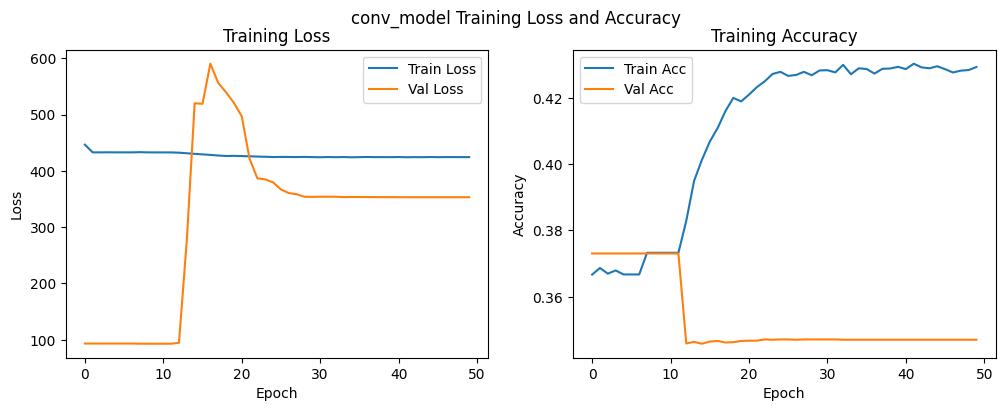

0.3730641592920354

In [32]:
# Гиперпараметры
learning_rate = 0.01
num_epochs = 50
patience = 5  # Количество эпох для уменьшения loss

# Функция потерь и оптимизатор
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_conv.parameters(), lr=learning_rate)

# Шедулер для уменьшения learning rate
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=patience, verbose=True)

# Обучаем модель
train_model(model_conv, train_loader, val_loader, 
            criterion=criterion, optimizer=optimizer, 
            scheduler=scheduler, num_epochs=num_epochs, 
            device=device, name_model='conv_model',
            save_dir=save_models_dir)

In [33]:
# Получаем предсказания для обучающей, валидационной и тестовой выборок
y_true_train, y_pred_train, y_prob_train = get_predictions(model_conv, train_loader, device)
y_true_val, y_pred_val, y_prob_val = get_predictions(model_conv, val_loader, device)
y_true_test, y_pred_test, y_prob_test = get_predictions(model_conv, test_loader, device)

# Оцениваем модель
evaluate_model(y_true_train, y_pred_train, y_prob_train, "обучающей")
evaluate_model(y_true_val, y_pred_val, y_prob_val, "валидационной")
evaluate_model(y_true_test, y_pred_test, y_prob_test, "тестовой")


=== Метрики для обучающей выборки ===

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.36      0.65      0.46     17880
     Class 1       0.00      0.00      0.00     13917
     Class 2       0.38      0.37      0.38     18938

    accuracy                           0.37     50735
   macro avg       0.25      0.34      0.28     50735
weighted avg       0.27      0.37      0.30     50735

ROC AUC (OvR, macro): 0.5058

=== Метрики для валидационной выборки ===

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.34      0.81      0.48      3712
     Class 1       0.00      0.00      0.00      3089
     Class 2       0.36      0.18      0.24      4047

    accuracy                           0.35     10848
   macro avg       0.23      0.33      0.24     10848
weighted avg       0.25      0.35      0.26     10848

ROC AUC (OvR, macro): 0.5095

=== Метрики для тестовой выборки ===

Classificat

## Conv + LSTM

In [34]:
class ConvLstmClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_lstm_layers, num_classes):
        super(ConvLstmClassifier, self).__init__()

        self.conv1 = nn.Conv1d(in_channels=input_size, out_channels=64, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm1d(64)

        self.conv2 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm1d(128)

        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)

        self.lstm = nn.LSTM(
            input_size=128, 
            hidden_size=hidden_size, 
            num_layers=num_lstm_layers, 
            batch_first=True, 
            dropout=0.3
        )

        self.fc1 = nn.Linear(hidden_size, 100, bias=False)
        self.bn3 = nn.BatchNorm1d(100)
        self.fc2 = nn.Linear(100, num_classes)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = x.permute(0, 2, 1)

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.pool(x)

        x = x.permute(0, 2, 1)

        x, _ = self.lstm(x)
        
        x = x[:, -1, :]

        x = self.fc1(x)
        x = self.bn3(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)

        return x

In [35]:
input_size = X_train.shape[2]  # Количество фичей (num_features)
num_classes = 3  # Количество классов
hidden_size = 128  # Размер скрытого состояния LSTM
num_lstm_layers = 3  # Количество слоев LSTM

model_conv_lstm = ConvLstmClassifier(input_size=input_size, hidden_size=hidden_size, num_lstm_layers=num_lstm_layers, num_classes=num_classes)
model_conv_lstm.to(device)  # Перемещаем модель на устройство

ConvLstmClassifier(
  (conv1): Conv1d(70, 64, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (lstm): LSTM(128, 128, num_layers=3, batch_first=True, dropout=0.3)
  (fc1): Linear(in_features=128, out_features=100, bias=False)
  (bn3): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=100, out_features=3, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
)


Epoch [1/50], Train Loss: 1.2139 | Train Acc: 0.3082, Val Loss: 1.2297 | Val Acc: 0.3035
New best MODEL saved (Val Acc: 0.3035)

Epoch [2/50], Train Loss: 1.2131 | Train Acc: 0.3062, Val Loss: 1.2326 | Val Acc: 0.3029

Epoch [3/50], Train Loss: 1.2116 | Train Acc: 0.3069, Val Loss: 1.2302 | Val Acc: 0.3031

Epoch [4/50], Train Loss: 1.2120 | Train Acc: 0.3124, Val Loss: 1.2289 | Val Acc: 0.3029

Epoch [5/50], Train Loss: 1.2107 | Train Acc: 0.3113, Val Loss: 1.2248 | Val Acc: 0.3037
New best MODEL saved (Val Acc: 0.3037)

Epoch [6/50], Train Loss: 1.2125 | Train Acc: 0.3071, Val Loss: 1.2332 | Val Acc: 0.3026

Epoch [7/50], Train Loss: 1.2150 | Train Acc: 0.3044, Val Loss: 1.2311 | Val Acc: 0.3033

Epoch [8/50], Train Loss: 1.2134 | Train Acc: 0.3110, Val Loss: 1.2287 | Val Acc: 0.3027

Epoch [9/50], Train Loss: 1.2102 | Train Acc: 0.3092, Val Loss: 1.2282 | Val Acc: 0.3033

Epoch [10/50], Train Loss: 1.2144 | Train Acc: 0.3063, Val Loss: 1.2287 | Val Acc: 0.3029

Epoch [11/50], Train

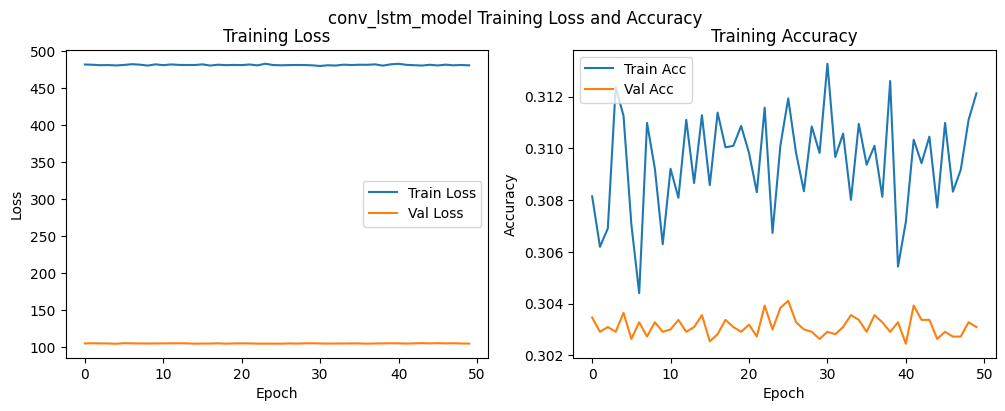

0.3041113569321534

In [36]:
# Гиперпараметры
learning_rate = 0.001
num_epochs = 50
patience = 5  # Количество эпох для уменьшения loss

# Функция потерь и оптимизатор
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_conv.parameters(), lr=learning_rate)

# Шедулер для уменьшения learning rate
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=patience, verbose=True)

# Обучаем модель
train_model(model_conv_lstm, train_loader, val_loader, 
            criterion=criterion, optimizer=optimizer, 
            scheduler=scheduler, num_epochs=num_epochs, 
            device=device, name_model='conv_lstm_model',
            save_dir=save_models_dir)

In [37]:
# Получаем предсказания для обучающей, валидационной и тестовой выборок
y_true_train, y_pred_train, y_prob_train = get_predictions(model_conv_lstm, train_loader, device)
y_true_val, y_pred_val, y_prob_val = get_predictions(model_conv_lstm, val_loader, device)
y_true_test, y_pred_test, y_prob_test = get_predictions(model_conv_lstm, test_loader, device)

# Оцениваем модель
evaluate_model(y_true_train, y_pred_train, y_prob_train, "обучающей")
evaluate_model(y_true_val, y_pred_val, y_prob_val, "валидационной")
evaluate_model(y_true_test, y_pred_test, y_prob_test, "тестовой")


=== Метрики для обучающей выборки ===

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.36      0.23      0.28     17880
     Class 1       0.29      0.79      0.42     13917
     Class 2       0.42      0.02      0.04     18938

    accuracy                           0.31     50735
   macro avg       0.36      0.35      0.25     50735
weighted avg       0.36      0.31      0.23     50735

ROC AUC (OvR, macro): 0.5019

=== Метрики для валидационной выборки ===

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.39      0.13      0.19      3712
     Class 1       0.29      0.89      0.44      3089
     Class 2       0.52      0.01      0.02      4047

    accuracy                           0.30     10848
   macro avg       0.40      0.34      0.22     10848
weighted avg       0.41      0.30      0.20     10848

ROC AUC (OvR, macro): 0.4875

=== Метрики для тестовой выборки ===

Classificat

Точность модели составляет около 33%. Сети не видят закономерностей, просто угадывание. Попробуем более мощные архитектуры.

## TSmixer Multihead AdAttention Conv1d

In [38]:
class TSmixer(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(TSmixer, self).__init__()
        
        # Входной слой
        self.input_proj = nn.Linear(input_size, hidden_size)
        
        # Сверточные слои
        self.conv_layers = nn.ModuleList([
            nn.Conv1d(in_channels=hidden_size, out_channels=hidden_size, kernel_size=3, padding=1)
            for _ in range(num_layers)
        ])
        
        # Слои внимания
        self.attention_layers = nn.ModuleList([
            nn.MultiheadAttention(embed_dim=hidden_size, num_heads=4)
            for _ in range(num_layers)
        ])
        
        # Выходной слой
        self.output_proj = nn.Linear(hidden_size, num_classes)
        
        # Нормализация
        self.layer_norm = nn.LayerNorm(hidden_size)
        
        # Dropout
        self.dropout = nn.Dropout(0.5)
    
    def forward(self, x):
        
        x = self.input_proj(x)  # (batch_size, window_size, hidden_size)
        x = x.permute(1, 0, 2)  # (window_size, batch_size, hidden_size)
        
        for conv, attention in zip(self.conv_layers, self.attention_layers):
            # Сверточный слой
            residual = x
            x = x.permute(1, 2, 0)  # (batch_size, hidden_size, window_size)
            x = conv(x)  # (batch_size, hidden_size, window_size)
            x = x.permute(2, 0, 1)  # (window_size, batch_size, hidden_size)
            x = self.layer_norm(x + residual)
            
            # Механизм внимания
            residual = x
            x, _ = attention(x, x, x)  # (window_size, batch_size, hidden_size)
            x = self.layer_norm(x + residual)
            x = self.dropout(x)
        
        # Возвращаемся к исходной размерности
        x = x.permute(1, 0, 2)  # (batch_size, window_size, hidden_size)
        
        # Усреднение по временной оси
        x = x.mean(dim=1)  # (batch_size, hidden_size)
        
        # Выходной слой
        x = self.output_proj(x)  # (batch_size, num_classes)
        
        return x


Epoch [1/70], Train Loss: 1.0923 | Train Acc: 0.3703, Val Loss: 1.0975 | Val Acc: 0.3679
New best MODEL saved (Val Acc: 0.3679)

Epoch [2/70], Train Loss: 1.0806 | Train Acc: 0.3859, Val Loss: 1.1588 | Val Acc: 0.3552

Epoch [3/70], Train Loss: 1.0782 | Train Acc: 0.3914, Val Loss: 1.1633 | Val Acc: 0.3748
New best MODEL saved (Val Acc: 0.3748)

Epoch [4/70], Train Loss: 1.0755 | Train Acc: 0.3906, Val Loss: 1.0968 | Val Acc: 0.3901
New best MODEL saved (Val Acc: 0.3901)

Epoch [5/70], Train Loss: 1.0742 | Train Acc: 0.3951, Val Loss: 1.0889 | Val Acc: 0.3871

Epoch [6/70], Train Loss: 1.0733 | Train Acc: 0.3960, Val Loss: 1.0916 | Val Acc: 0.3902
New best MODEL saved (Val Acc: 0.3902)

Epoch [7/70], Train Loss: 1.0733 | Train Acc: 0.3960, Val Loss: 1.1129 | Val Acc: 0.3870

Epoch [8/70], Train Loss: 1.0723 | Train Acc: 0.3945, Val Loss: 1.0997 | Val Acc: 0.3846

Epoch [9/70], Train Loss: 1.0729 | Train Acc: 0.3961, Val Loss: 1.0872 | Val Acc: 0.3942
New best MODEL saved (Val Acc: 0.3

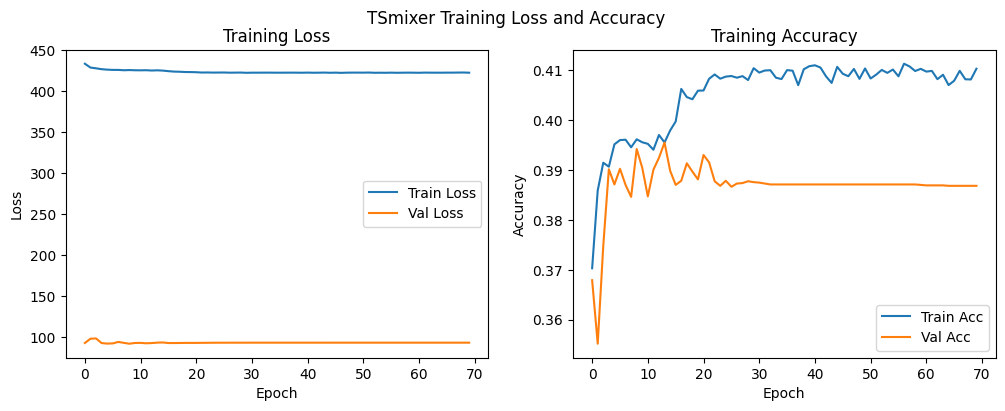

0.3954646017699115

In [39]:
num_classes = 3
input_size = X_train_tensor.shape[-1]
hidden_size = 64
num_layers = 4

TS_attention_model = TSmixer(input_size, hidden_size, num_layers, num_classes)
TS_attention_model.to(device)  # Перемещаем модель на устройство (GPU или CPU)

learning_rate = 0.001
num_epochs = 70
patience = 5  # Количество эпох для уменьшения loss

# Функция потерь и оптимизатор
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(TS_attention_model.parameters(), lr=learning_rate)

# Шедулер для уменьшения learning rate
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=patience, verbose=True)

train_model(
    model=TS_attention_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=num_epochs,
    device=device,
    name_model="TSmixer",
    save_dir=save_models_dir
)

In [40]:

TS_attention_model = TSmixer(input_size, hidden_size, num_layers, num_classes)
TS_attention_model.load_state_dict(torch.load('../models/best_models_raw/TSmixer_best_acc.pth'))
TS_attention_model.to(device)
TS_attention_model.eval()

TSmixer(
  (input_proj): Linear(in_features=70, out_features=64, bias=True)
  (conv_layers): ModuleList(
    (0-3): 4 x Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  )
  (attention_layers): ModuleList(
    (0-3): 4 x MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
    )
  )
  (output_proj): Linear(in_features=64, out_features=3, bias=True)
  (layer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

In [41]:
# Получаем предсказания для обучающей, валидационной и тестовой выборок
y_true_train, y_pred_train, y_prob_train = get_predictions(TS_attention_model, train_loader, device)
y_true_val, y_pred_val, y_prob_val = get_predictions(TS_attention_model, val_loader, device)
y_true_test, y_pred_test, y_prob_test = get_predictions(TS_attention_model, test_loader, device)


In [42]:
# Оцениваем модель
evaluate_model(y_true_train, y_pred_train, y_prob_train, "обучающей")
evaluate_model(y_true_val, y_pred_val, y_prob_val, "валидационной")
evaluate_model(y_true_test, y_pred_test, y_prob_test, "тестовой")


=== Метрики для обучающей выборки ===

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.39      0.00      0.01     17880
     Class 1       0.36      0.52      0.42     13917
     Class 2       0.41      0.65      0.50     18938

    accuracy                           0.39     50735
   macro avg       0.38      0.39      0.31     50735
weighted avg       0.39      0.39      0.31     50735

ROC AUC (OvR, macro): 0.5694

=== Метрики для валидационной выборки ===

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.38      0.00      0.01      3712
     Class 1       0.38      0.40      0.39      3089
     Class 2       0.40      0.75      0.52      4047

    accuracy                           0.40     10848
   macro avg       0.39      0.39      0.31     10848
weighted avg       0.39      0.40      0.31     10848

ROC AUC (OvR, macro): 0.5591

=== Метрики для тестовой выборки ===

Classificat

есть небольшое улучшение точности, надо будет поэкспериментировать с гиперпараметрами

## Transfnsformer

In [43]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.encoding = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-torch.log(torch.tensor(10000.0)) / d_model))
        self.encoding[:, 0::2] = torch.sin(position * div_term)
        self.encoding[:, 1::2] = torch.cos(position * div_term)
        self.encoding = self.encoding.unsqueeze(0)  # [1, max_len, d_model]

    def forward(self, x):
        # x shape: [Batch, Seq_len, d_model]
        return x + self.encoding[:, :x.size(1), :].to(x.device)

In [44]:
class TransformerClassifier(nn.Module):
    def __init__(self, input_shape, num_classes, d_model=64, nhead=4, num_encoder_layers=2, dim_feedforward=256, dropout_rate=0.1):
        super(TransformerClassifier, self).__init__()
        seq_len, num_features = input_shape  # [Seq_len, Features]

        # Linear projection для увеличения размерности фичей до d_model
        self.input_proj = nn.Linear(num_features, d_model)

        # Positional Encoding
        self.pos_encoder = PositionalEncoding(d_model, max_len=seq_len)

        # Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout_rate
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_encoder_layers)

        # Global Average Pooling
        self.global_avg_pool = nn.AdaptiveAvgPool1d(1)

        # Классификатор
        self.fc = nn.Linear(d_model, num_classes)

    def forward(self, x):
        # x shape: [Batch, Seq_len, Features]
        x = self.input_proj(x)  # [Batch, Seq_len, d_model]

        # Добавляем positional encoding
        x = self.pos_encoder(x)

        # Трансформер ожидает [Seq_len, Batch, d_model], поэтому меняем оси
        x = x.permute(1, 0, 2)  # [Seq_len, Batch, d_model]

        # Применяем трансформер
        x = self.transformer_encoder(x)  # [Seq_len, Batch, d_model]

        # Меняем оси обратно
        x = x.permute(1, 2, 0)  # [Batch, d_model, Seq_len]

        # Global Average Pooling
        x = self.global_avg_pool(x)  # [Batch, d_model, 1]
        x = x.squeeze(-1)  # [Batch, d_model]

        # Классификация
        x = self.fc(x)  # [Batch, num_classes]

        return x


Epoch [1/50], Train Loss: 1.0839 | Train Acc: 0.3763, Val Loss: 1.1281 | Val Acc: 0.3536
New best MODEL saved (Val Acc: 0.3536)

Epoch [2/50], Train Loss: 1.0775 | Train Acc: 0.3814, Val Loss: 1.1077 | Val Acc: 0.3578
New best MODEL saved (Val Acc: 0.3578)

Epoch [3/50], Train Loss: 1.0750 | Train Acc: 0.3842, Val Loss: 1.1023 | Val Acc: 0.3694
New best MODEL saved (Val Acc: 0.3694)

Epoch [4/50], Train Loss: 1.0729 | Train Acc: 0.3866, Val Loss: 1.0978 | Val Acc: 0.3717
New best MODEL saved (Val Acc: 0.3717)

Epoch [5/50], Train Loss: 1.0710 | Train Acc: 0.3908, Val Loss: 1.0959 | Val Acc: 0.3734
New best MODEL saved (Val Acc: 0.3734)

Epoch [6/50], Train Loss: 1.0695 | Train Acc: 0.3937, Val Loss: 1.0948 | Val Acc: 0.3763
New best MODEL saved (Val Acc: 0.3763)

Epoch [7/50], Train Loss: 1.0685 | Train Acc: 0.3946, Val Loss: 1.0962 | Val Acc: 0.3787
New best MODEL saved (Val Acc: 0.3787)

Epoch [8/50], Train Loss: 1.0672 | Train Acc: 0.3983, Val Loss: 1.0952 | Val Acc: 0.3814
New bes

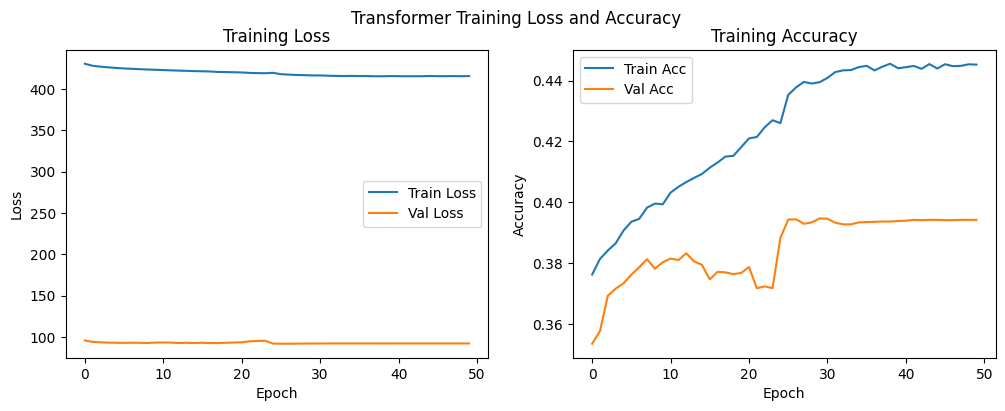

0.39472713864306785

In [52]:
input_shape = list(X_train_tensor.shape[1:])  # [Input Length, Channel]
num_classes = num_classes  # Количество классов
d_model = 16 # Размерность модели трансформера
nhead = 4 # Количество голов в механизме внимания
num_encoder_layers = 2  # Количество слоев трансформера
dim_feedforward = 32  # Размерность внутреннего слоя feedforward network
dropout_rate = 0.1  # Коэффициент dropout

transformer = TransformerClassifier(input_shape, num_classes, d_model=d_model, nhead=nhead, num_encoder_layers=num_encoder_layers, dim_feedforward=dim_feedforward, dropout_rate=dropout_rate)
transformer.to(device) 

learning_rate = 0.001
num_epochs = 50
patience = 5  # Количество эпох для уменьшения loss

# Функция потерь и оптимизатор
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(transformer.parameters(), lr=learning_rate)

# Шедулер для уменьшения learning rate
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=patience, verbose=True)

# Train model
model_name = "Transformer"
train_model(
    model=transformer,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=num_epochs,
    device=device,
    name_model=model_name,
    save_dir=save_models_dir
)

In [53]:
# Загрузка лучшей модели
transformer = TransformerClassifier(input_shape, num_classes, d_model=d_model, nhead=nhead, num_encoder_layers=num_encoder_layers, dim_feedforward=dim_feedforward, dropout_rate=dropout_rate)
transformer.load_state_dict(torch.load('../models/best_models_raw/Transformer_best_acc.pth'))
transformer.to(device)
transformer.eval()

TransformerClassifier(
  (input_proj): Linear(in_features=70, out_features=16, bias=True)
  (pos_encoder): PositionalEncoding()
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=16, out_features=16, bias=True)
        )
        (linear1): Linear(in_features=16, out_features=32, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=32, out_features=16, bias=True)
        (norm1): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (global_avg_pool): AdaptiveAvgPool1d(output_size=1)
  (fc): Linear(in_features=16, out_features=3, bias=True)
)

In [54]:
# Получаем предсказания для обучающей, валидационной и тестовой выборок
y_true_train, y_pred_train, y_prob_train = get_predictions(transformer, train_loader, device)
y_true_val, y_pred_val, y_prob_val = get_predictions(transformer, val_loader, device)
y_true_test, y_pred_test, y_prob_test = get_predictions(transformer, test_loader, device)

# Оцениваем модель
evaluate_model(y_true_train, y_pred_train, y_prob_train, "обучающей")
evaluate_model(y_true_val, y_pred_val, y_prob_val, "валидационной")
evaluate_model(y_true_test, y_pred_test, y_prob_test, "тестовой")


=== Метрики для обучающей выборки ===

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.43      0.48      0.45     17880
     Class 1       0.45      0.31      0.37     13917
     Class 2       0.46      0.51      0.49     18938

    accuracy                           0.45     50735
   macro avg       0.45      0.44      0.44     50735
weighted avg       0.45      0.45      0.44     50735

ROC AUC (OvR, macro): 0.6259

=== Метрики для валидационной выборки ===

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.38      0.46      0.42      3712
     Class 1       0.38      0.40      0.39      3089
     Class 2       0.42      0.33      0.37      4047

    accuracy                           0.39     10848
   macro avg       0.40      0.40      0.39     10848
weighted avg       0.40      0.39      0.39     10848

ROC AUC (OvR, macro): 0.5725

=== Метрики для тестовой выборки ===

Classificat

## ResNet1D

In [48]:
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, dropout_rate=0.5):
        super(BasicBlock, self).__init__()
        # Первый Conv1d слой
        self.conv1 = nn.Conv1d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            stride=stride,
            padding=kernel_size // 2,  # Сохраняет размерность
            bias=False
        )
        self.bn1 = nn.BatchNorm1d(out_channels)  # BatchNorm
        self.relu = nn.ReLU(inplace=True)
        self.dropout1 = nn.Dropout(dropout_rate)

        # Второй Conv1d слой
        self.conv2 = nn.Conv1d(
            in_channels=out_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            stride=1,
            padding=kernel_size // 2,
            bias=False
        )
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.dropout2 = nn.Dropout(dropout_rate)

        # Остаточное соединение
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(
                    in_channels=in_channels,
                    out_channels=out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm1d(out_channels)
            )

    def forward(self, x):
        residual = x

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout1(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.dropout2(x)

        residual = self.shortcut(residual)
        x += residual

        x = self.relu(x)

        return x


class ResNet1D(nn.Module):
    def __init__(self, input_shape, num_classes, num_blocks=[2, 2, 2], initial_channels=64, dropout_rate=0.5):
        super(ResNet1D, self).__init__()
        seq_len, num_features = input_shape  # [Seq_len, Features]

        # Начальный слой
        self.initial_conv = nn.Sequential(
            nn.Conv1d(
                in_channels=num_features,
                out_channels=initial_channels,
                kernel_size=7,
                stride=2,
                padding=3,
                bias=False
            ),
            nn.BatchNorm1d(initial_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=3, stride=2, padding=1)
        )

        # Residual Blocks
        self.layer1 = self._make_layer(initial_channels, initial_channels, num_blocks[0], stride=1, dropout_rate=dropout_rate)
        self.layer2 = self._make_layer(initial_channels, initial_channels * 2, num_blocks[1], stride=2, dropout_rate=dropout_rate)

        # Global Average Pooling
        self.global_avg_pool = nn.AdaptiveAvgPool1d(1)

        # Классификатор
        self.fc = nn.Linear(initial_channels * 2, num_classes)

    def _make_layer(self, in_channels, out_channels, num_blocks, stride, dropout_rate):
        layers = []
        # Первый блок с изменением размерности
        layers.append(BasicBlock(in_channels, out_channels, stride=stride, dropout_rate=dropout_rate))
        # Остальные блоки
        for _ in range(1, num_blocks):
            layers.append(BasicBlock(out_channels, out_channels, stride=1, dropout_rate=dropout_rate))
        return nn.Sequential(*layers)

    def forward(self, x):
        # x shape: [Batch, Seq_len, Features]
        x = x.permute(0, 2, 1)  # [Batch, Features, Seq_len]

        # Начальный слой
        x = self.initial_conv(x)

        # Residual Blocks
        x = self.layer1(x)
        x = self.layer2(x)

        x = self.global_avg_pool(x)
        x = x.squeeze(-1)

        x = self.fc(x)

        return x


Epoch [1/50], Train Loss: 1.0731 | Train Acc: 0.4264, Val Loss: 4.7824 | Val Acc: 0.3485
New best MODEL saved (Val Acc: 0.3485)

Epoch [2/50], Train Loss: 1.0468 | Train Acc: 0.4586, Val Loss: 8.8789 | Val Acc: 0.3489
New best MODEL saved (Val Acc: 0.3489)

Epoch [3/50], Train Loss: 1.0305 | Train Acc: 0.4767, Val Loss: 7.2546 | Val Acc: 0.3469

Epoch [4/50], Train Loss: 1.0168 | Train Acc: 0.4888, Val Loss: 6.3001 | Val Acc: 0.3477

Epoch [5/50], Train Loss: 1.0055 | Train Acc: 0.4994, Val Loss: 4.1533 | Val Acc: 0.3469

Epoch [6/50], Train Loss: 0.9972 | Train Acc: 0.5062, Val Loss: 4.2480 | Val Acc: 0.3482

Epoch [7/50], Train Loss: 0.9879 | Train Acc: 0.5148, Val Loss: 4.6197 | Val Acc: 0.3484

Epoch [8/50], Train Loss: 0.9776 | Train Acc: 0.5201, Val Loss: 3.0986 | Val Acc: 0.3532
New best MODEL saved (Val Acc: 0.3532)

Epoch [9/50], Train Loss: 0.9701 | Train Acc: 0.5279, Val Loss: 2.4216 | Val Acc: 0.3633
New best MODEL saved (Val Acc: 0.3633)

Epoch [10/50], Train Loss: 0.9624

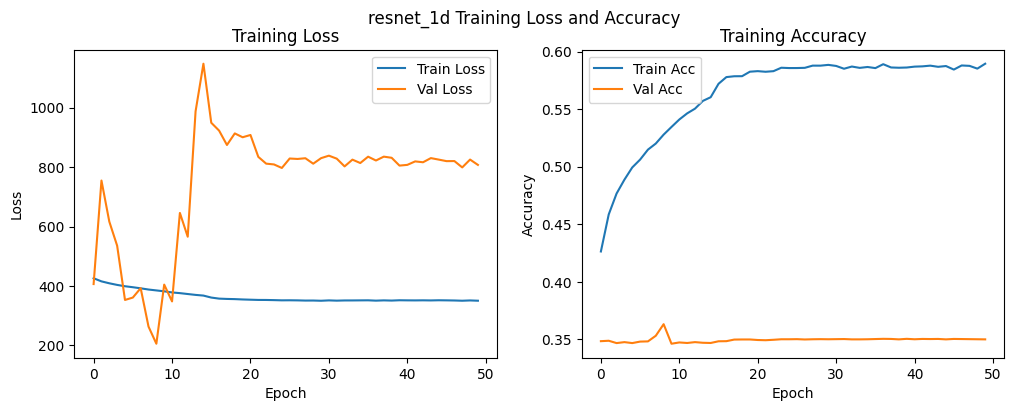

In [49]:
input_shape = input_shape = list(X_train_tensor.shape[1:])  # [Seq_len, Features]
num_classes = 3  # Количество классов
num_blocks = [1, 1]  # Количество блоков в каждом слое
initial_channels = 32  # Начальное количество каналов
dropout_rate = 0.2  # Dropout rate

# Инициализация модели
resnet_1d = ResNet1D(
    input_shape=input_shape,
    num_classes=num_classes,
    num_blocks=num_blocks,
    initial_channels=initial_channels,
    dropout_rate=dropout_rate
)
resnet_1d.to(device) 

learning_rate = 0.001
num_epochs = 50
patience = 5  # Количество эпох для уменьшения loss

# Функция потерь и оптимизатор
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet_1d.parameters(), lr=learning_rate)

# Шедулер для уменьшения learning rate
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=patience, verbose=True)

# Train model
model_name = "resnet_1d"
metrics = train_model(
    model=resnet_1d,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=num_epochs,
    device=device,
    name_model=model_name,
    save_dir=save_models_dir
)

In [50]:
resnet_1d = ResNet1D(
        input_shape=input_shape,
        num_classes=num_classes,
        num_blocks=num_blocks,
        initial_channels=initial_channels,
        dropout_rate=dropout_rate
    )

resnet_1d.load_state_dict(torch.load('../models/best_models_raw/resnet_1d_best_acc.pth'))
resnet_1d.to(device)
resnet_1d.eval()

ResNet1D(
  (initial_conv): Sequential(
    (0): Conv1d(70, 32, kernel_size=(7,), stride=(2,), padding=(3,), bias=False)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool1d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
      (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (dropout1): Dropout(p=0.2, inplace=False)
      (conv2): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
      (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (dropout2): Dropout(p=0.2, inplace=False)
      (shortcut): Sequential()
    )
  )
  (layer2): Sequential(
    (0): BasicBlock(
      (conv1): Conv1d(32, 64, kernel_size=(3,), stride

In [51]:
# Получаем предсказания для обучающей, валидационной и тестовой выборок
y_true_train, y_pred_train, y_prob_train = get_predictions(resnet_1d, train_loader, device)
y_true_val, y_pred_val, y_prob_val = get_predictions(resnet_1d, val_loader, device)
y_true_test, y_pred_test, y_prob_test = get_predictions(resnet_1d, test_loader, device)

# Оцениваем модель
evaluate_model(y_true_train, y_pred_train, y_prob_train, "обучающей")
evaluate_model(y_true_val, y_pred_val, y_prob_val, "валидационной")
evaluate_model(y_true_test, y_pred_test, y_prob_test, "тестовой")


=== Метрики для обучающей выборки ===

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.36      0.47      0.40     17880
     Class 1       0.31      0.00      0.00     13917
     Class 2       0.39      0.55      0.45     18938

    accuracy                           0.37     50735
   macro avg       0.35      0.34      0.29     50735
weighted avg       0.35      0.37      0.31     50735

ROC AUC (OvR, macro): 0.5146

=== Метрики для валидационной выборки ===

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.34      0.58      0.43      3712
     Class 1       0.67      0.00      0.00      3089
     Class 2       0.39      0.45      0.42      4047

    accuracy                           0.36     10848
   macro avg       0.47      0.34      0.28     10848
weighted avg       0.45      0.36      0.30     10848

ROC AUC (OvR, macro): 0.5175

=== Метрики для тестовой выборки ===

Classificat

Лучшие результаты на валидационной и тестовой выборках показал Трансформер (у него же самый стабильный classification report). Но все модели показали слабые результаты. Далее нужно попробовать оптимизировать гиперпараметры.